# Exp7.3.6 — Affine mean-head bridge

Analysis-only notebook. It reads finalized Exp7.3.6 artifacts and summarizes method-level effects of bias, scale conditioning, and LIF realization.

In [2]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start=None):
    p = Path.cwd() if start is None else Path(start)
    for candidate in [p, *p.parents]:
        if (candidate / 'AGENTS.md').exists():
            return candidate
    raise FileNotFoundError('Repository root not found')

REPO_ROOT = find_repo_root()
ROOT = REPO_ROOT / 'notebooks' / 'artifacts' / 'experiment_7_3_6_affine_mean_head_bridge' / 'affine_mean_head_bridge_v1'
runs = pd.read_csv(ROOT / 'method_runs.csv')
summary = pd.read_csv(ROOT / 'method_summary.csv')
contrasts = pd.read_csv(ROOT / 'contrast_summary.csv')
bias = pd.read_csv(ROOT / 'bias_ablation.csv')
lif = pd.read_csv(ROOT / 'lif_realization_summary.csv')
history = pd.read_csv(ROOT / 'history_summary.csv')
source_checks = json.loads((ROOT / 'source_reproduction_checks.json').read_text())
manifest = json.loads((ROOT / 'manifest.json').read_text())


## Primary analog comparison

In [3]:
display(summary[['method', 'analog_test_ba_mean', 'analog_test_ba_std', 'lif_test_ba_mean', 'lif_test_ba_std']])
display(contrasts)
print('P3 mean-affine reference:', source_checks.get('p3_mean_affine_test_ba'))
print('P7 whole-count affine reference:', source_checks.get('p7_wholecount_affine_test_ba'))


,method,analog_test_ba_mean,analog_test_ba_std,lif_test_ba_mean,lif_test_ba_std
0,H0_raw_no_bias,0.552707,0.036762,0.522762,0.012987
1,H1_raw_bias,0.547328,0.031565,0.528278,0.016795
2,H2_scale_no_bias,0.551949,0.036434,0.522897,0.019631
3,H3_scale_bias,0.551696,0.036270,0.517486,0.007077


,contrast,left_method,right_method,delta_pp_count,delta_pp_mean,delta_pp_std
0,bias_raw_H1_minus_H0,H1_raw_bias,H0_raw_no_bias,3,-0.537819,2.189243
1,bias_scaled_H3_minus_H2,H3_scale_bias,H2_scale_no_bias,3,-0.025253,0.043739
2,full_H3_minus_H0,H3_scale_bias,H0_raw_no_bias,3,-0.101010,0.558837
3,scale_no_bias_H2_minus_H0,H2_scale_no_bias,H0_raw_no_bias,3,-0.075758,0.518239


P3 mean-affine reference: 0.5567756317756317
P7 whole-count affine reference: 0.5862734487734488


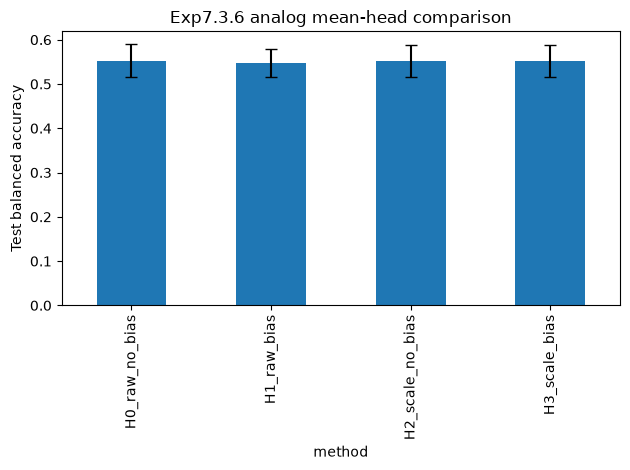

In [4]:
plot_df = summary.set_index('method').loc[[
    'H0_raw_no_bias',
    'H1_raw_bias',
    'H2_scale_no_bias',
    'H3_scale_bias',
]]
ax = plot_df['analog_test_ba_mean'].plot(kind='bar', yerr=plot_df['analog_test_ba_std'], capsize=4)
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Exp7.3.6 analog mean-head comparison')
plt.tight_layout()
plt.show()


## Bias ablation

In [5]:
display(bias[['method', 'seed', 'analog_test_ba', 'bias_off_test_ba', 'direct_bias_effect_pp']])
display(bias.groupby('method')['direct_bias_effect_pp'].agg(['mean', 'std']))


,method,seed,analog_test_ba,bias_off_test_ba,direct_bias_effect_pp
0,H1_raw_bias,11,0.517834,0.510258,0.757576
1,H1_raw_bias,23,0.543531,0.545154,-0.162338
2,H1_raw_bias,37,0.580620,0.561771,1.884921
3,H3_scale_bias,11,0.510258,0.502683,0.757576
4,H3_scale_bias,23,0.567151,0.573103,-0.595238
5,H3_scale_bias,37,0.577680,0.577680,0.000000


,mean,std
method,,
H1_raw_bias,0.826720,1.025379
H3_scale_bias,0.054113,0.678028


## Analog-to-spiking realization

,method,seed,analog_test_ba,lif_test_ba,if_count_test_ba,if_charge_test_ba,if_charge_max_abs_error
0,H0_raw_no_bias,11,0.510258,0.507986,0.326321,0.510258,0.000122
1,H0_raw_no_bias,23,0.574186,0.527932,0.282776,0.574186,0.000183
2,H0_raw_no_bias,37,0.573676,0.532368,0.318179,0.573676,0.000183
3,H1_raw_bias,11,0.517834,0.516554,0.277026,0.517834,0.000259
4,H1_raw_bias,23,0.543531,0.520763,0.252488,0.543531,0.000214
5,H1_raw_bias,37,0.580620,0.547519,0.324673,0.580620,0.000229
6,H2_scale_no_bias,11,0.510258,0.521514,0.309494,0.510258,0.000153
7,H2_scale_no_bias,23,0.567908,0.543183,0.320754,0.567908,0.000244
8,H2_scale_no_bias,37,0.577680,0.503995,0.288532,0.577680,0.000244
9,H3_scale_bias,11,0.510258,0.515562,0.313958,0.510258,0.000351


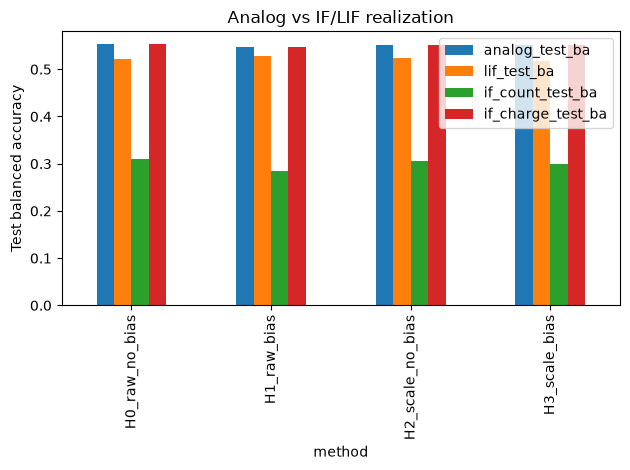

Max beta=1 charge identity error: 0.000640869140625


In [6]:
display(lif)
realization = lif.groupby('method')[['analog_test_ba', 'lif_test_ba', 'if_count_test_ba', 'if_charge_test_ba']].mean()
ax = realization.plot(kind='bar')
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Analog vs IF/LIF realization')
plt.tight_layout()
plt.show()
print('Max beta=1 charge identity error:', manifest['max_if_charge_identity_abs_error'])


## Training histories

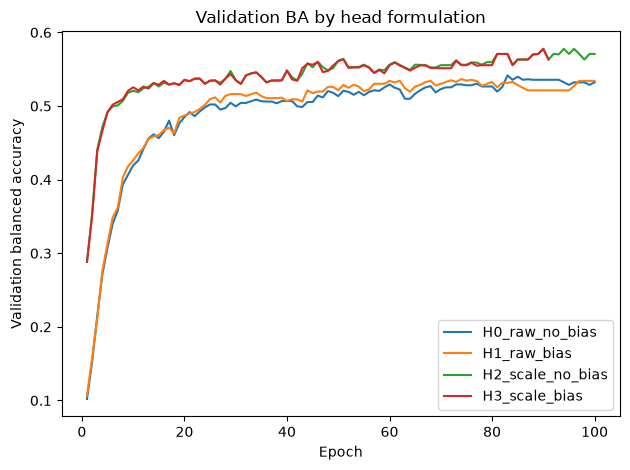

In [7]:
for method, df in history.groupby('method'):
    plt.plot(df['epoch'], df['val_ba_mean'], label=method)
plt.xlabel('Epoch')
plt.ylabel('Validation balanced accuracy')
plt.title('Validation BA by head formulation')
plt.legend()
plt.tight_layout()
plt.show()
